In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from pathlib import Path

In [117]:

# URLs de Inside Airbnb para Madrid
URL_LISTINGS = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2025-09-14/visualisations/listings.csv"
URL_LISTINGS_DEV = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2025-09-14/data/listings.csv.gz"

# Importación de datos
listings = pd.read_csv(URL_LISTINGS)
listings_det = pd.read_csv(URL_LISTINGS_DEV, compression="gzip")


In [118]:
listings.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,NaN,4,33,2018-07-15,0.25,2,198,0,NaN
1,30320,Apartamentos Dana Sol,130907,Danuta Weronika,Centro,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,173,2025-08-27,0.93,17,342,1,NaN
2,30959,Beautiful loft in Madrid Center,132883,Angela,Centro,Embajadores,40.41259,-3.70105,Entire home/apt,NaN,3,8,2017-05-30,0.06,1,0,0,NaN
3,40916,Apartasol Apartamentos Dana,130907,Danuta Weronika,Centro,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,53,2025-09-11,0.29,17,341,4,NaN
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,303845,Arturo,Centro,Justicia,40.41884,-3.69655,Private room,65.0,1,249,2025-09-05,2.78,3,299,41,NaN


In [119]:
listings.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='str')

In [120]:
a_eliminar = [ 'host_name', 'host_id', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'license' ]

# Eliminamos las columnas innecesarias
listings = listings.drop(columns=a_eliminar)

In [121]:
listings.head()

,id,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,availability_365
0,21853,Bright and airy room,Latina,Cármenes,40.40381,-3.74130,Private room,NaN,4,198
1,30320,Apartamentos Dana Sol,Centro,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,342
2,30959,Beautiful loft in Madrid Center,Centro,Embajadores,40.41259,-3.70105,Entire home/apt,NaN,3,0
3,40916,Apartasol Apartamentos Dana,Centro,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,341
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Centro,Justicia,40.41884,-3.69655,Private room,65.0,1,299


In [122]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   25000 non-null  int64  
 1   name                 25000 non-null  str    
 2   neighbourhood_group  25000 non-null  str    
 3   neighbourhood        25000 non-null  str    
 4   latitude             25000 non-null  float64
 5   longitude            25000 non-null  float64
 6   room_type            25000 non-null  str    
 7   price                18953 non-null  float64
 8   minimum_nights       25000 non-null  int64  
 9   availability_365     25000 non-null  int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 1.9 MB


In [123]:
# analisis de nulos
listings.isnull().sum()

id                        0
name                      0
neighbourhood_group       0
neighbourhood             0
latitude                  0
longitude                 0
room_type                 0
price                  6047
minimum_nights            0
availability_365          0
dtype: int64

In [124]:
# eliminamos filas con nulos
listings = listings.dropna()

In [125]:
# verificamos que no hay filas duplicadas
listings.duplicated().sum()

np.int64(0)

In [126]:
# Value counts de las variables categóricas
cols_object = listings.select_dtypes(include="object").columns

for col in cols_object:
    print(f"\n{'='*50}")
    print(f"Variable: {col}")
    print(f"{'='*50}")
    print(listings[col].value_counts(dropna=False))



Variable: name
name
Habitación en piso compartido                         179
Habitación con baño privado                            20
Habitación piso compartido                             16
Flamenco Style Apartment | Palacio Real, La Latina     14
Dobo SB20 2Pax 1Bth                                    14
                                                     ... 
Amplio apartamento con Terraza                          1
Piso de hasta 4 huéspedes en el centro de Madrid        1
Cozy Apartment Gran Via Wifi Air Conditioner/Heat       1
Casa Nido                                               1
Cómoda habitación muy céntrica.                         1
Name: count, Length: 17616, dtype: int64

Variable: neighbourhood_group
neighbourhood_group
Centro                   8094
Salamanca                1316
Tetuán                   1303
Chamberí                 1196
Arganzuela                905
Retiro                    727
Chamartín                 689
Carabanchel               661
Ciudad Li

C:\Users\phdel\AppData\Local\Temp\ipykernel_9008\2539222085.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_object = listings.select_dtypes(include="object").columns


In [127]:
# eliminar los registros ddnde room_type sea igual a Hotel room
listings = listings[listings["room_type"] != "Hotel room"]

In [128]:
listings.iloc[:, 7:10].describe().T

,count,mean,std,min,25%,50%,75%,max
price,18912.0,156.703574,492.779906,8.0,70.0,110.0,163.0,25654.0
minimum_nights,18912.0,8.379124,19.819202,1.0,1.0,2.0,4.0,600.0
availability_365,18912.0,213.170897,115.738906,0.0,98.0,246.0,318.0,365.0


<Axes: title={'center': 'Distribución de precios > 1000€'}, ylabel='Frequency'>

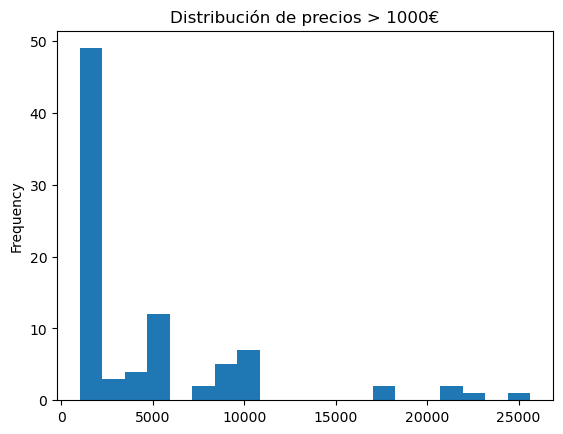

In [129]:
listings_filtrado = listings[listings["price"] > 1000]
listings_filtrado["price"].plot(kind="hist", bins=20, title="Distribución de precios > 1000€")


<Axes: title={'center': 'Distribución de precios entre 20 y 1000'}, ylabel='Frequency'>

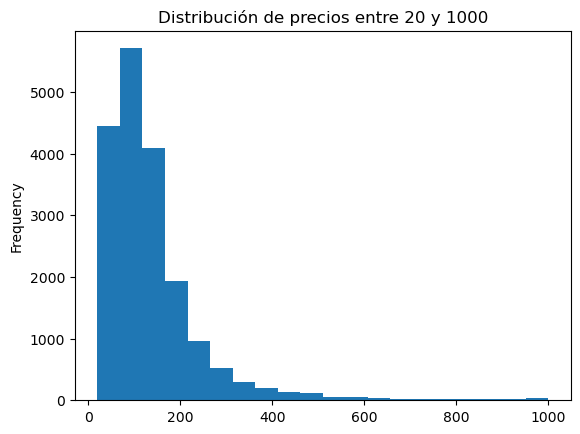

In [130]:
# quedarnos con filas cuyo precio sea mayor a 20 y menor a 1000 
listings = listings[(listings["price"] >= 20) & (listings["price"] <= 1000)]
listings["price"].plot(kind="hist", bins=20, title="Distribución de precios entre 20 y 1000")

In [131]:
listings.iloc[:, 7:10].describe().T

,count,mean,std,min,25%,50%,75%,max
price,18708.0,136.320344,112.262767,20.0,71.0,110.0,163.0,1000.0
minimum_nights,18708.0,8.268869,19.230556,1.0,1.0,2.0,4.0,366.0
availability_365,18708.0,213.330714,115.756118,0.0,98.0,246.0,318.0,365.0


In [132]:
listings_det.head(6)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250914152907,2025-09-15,previous scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,...,4.82,4.21,4.67,NaN,f,2,0,2,0,0.25
1,30320,https://www.airbnb.com/rooms/30320,20250914152907,2025-09-15,city scrape,Apartamentos Dana Sol,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409...,130907,...,4.78,4.90,4.69,NaN,t,17,17,0,0,0.93
2,30959,https://www.airbnb.com/rooms/30959,20250914152907,2025-09-15,previous scrape,Beautiful loft in Madrid Center,Beautiful Loft 60m2 size just in the historica...,NaN,https://a0.muscache.com/pictures/78173471/835e...,132883,...,4.63,4.88,4.25,NaN,f,1,1,0,0,0.06
3,40916,https://www.airbnb.com/rooms/40916,20250914152907,2025-09-15,city scrape,Apartasol Apartamentos Dana,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,130907,...,4.81,4.88,4.59,NaN,t,17,17,0,0,0.29
4,62423,https://www.airbnb.com/rooms/62423,20250914152907,2025-09-15,city scrape,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,DISTRICT WITH VERY GOOD VIBES IN THE MIDDLE OF...,https://a0.muscache.com/pictures/miso/Hosting-...,303845,...,4.86,4.97,4.60,NaN,f,3,1,2,0,2.78
5,70059,https://www.airbnb.com/rooms/70059,20250914152907,2025-09-15,previous scrape,Tu hogar en centro de Madrid.,"Very nice, cozy and bright, right in the cente...",The location of this apartment is ideal for wa...,https://a0.muscache.com/pictures/6479679/b14b9...,353616,...,4.89,4.95,4.54,VT-7440,f,1,1,0,0,0.36


In [133]:
listings_det.property_type.value_counts()

property_type
Entire rental unit             14893
Private room in rental unit     5855
Private room in home             752
Entire condo                     474
Entire loft                      471
                               ...  
Yurt                               1
Private room in pension            1
Private room in ryokan             1
Private room in tent               1
Shared room in guesthouse          1
Name: count, Length: 66, dtype: int64

In [134]:
listings_det.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            25000 non-null  int64  
 1   listing_url                                   25000 non-null  str    
 2   scrape_id                                     25000 non-null  int64  
 3   last_scraped                                  25000 non-null  str    
 4   source                                        25000 non-null  str    
 5   name                                          25000 non-null  str    
 6   description                                   24130 non-null  str    
 7   neighborhood_overview                         10586 non-null  str    
 8   picture_url                                   24999 non-null  str    
 9   host_id                                       25000 non-null  int64  
 1

In [135]:
a_incluir = [
    'id',
    'description',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'review_scores_location',
    'estimated_occupancy_l365d',
]

listings_det = listings_det[a_incluir]

In [136]:
listings_det.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         25000 non-null  int64  
 1   description                24130 non-null  str    
 2   accommodates               25000 non-null  int64  
 3   bathrooms                  18960 non-null  float64
 4   bedrooms                   22488 non-null  float64
 5   beds                       18965 non-null  float64
 6   review_scores_location     19850 non-null  float64
 7   estimated_occupancy_l365d  25000 non-null  int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 1.5 MB


In [137]:
# analisis de nulos
listings_det.isnull().sum()

id                              0
description                   870
accommodates                    0
bathrooms                    6040
bedrooms                     2512
beds                         6035
review_scores_location       5150
estimated_occupancy_l365d       0
dtype: int64

In [138]:
listings_det.head(5) 

,id,description,accommodates,bathrooms,bedrooms,beds,review_scores_location,estimated_occupancy_l365d
0,21853,We have a quiet and sunny room with a good vie...,1,NaN,NaN,NaN,4.21,0
1,30320,NaN,2,1.0,1.0,2.0,4.90,10
2,30959,Beautiful Loft 60m2 size just in the historica...,2,NaN,1.0,NaN,4.88,0
3,40916,NaN,2,1.0,1.0,3.0,4.88,40
4,62423,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,1.5,1.0,2.0,4.97,246


In [139]:
# numero de registros con estimated_occupancy_l365d igual a 0
listings_det[listings_det["estimated_occupancy_l365d"] == 0].shape[0]

8985

In [140]:
# eliminar los registros con estimated_occupancy_l365d igual a 0
listings_det = listings_det[listings_det["estimated_occupancy_l365d"] != 0]

In [141]:
listings_det.isnull().sum()

id                              0
description                   412
accommodates                    0
bathrooms                    1584
bedrooms                      515
beds                         1587
review_scores_location          0
estimated_occupancy_l365d       0
dtype: int64

In [142]:
listings_det.shape

(16015, 8)

In [143]:
listings_det.accommodates.value_counts(ascending=False)

accommodates
2     5534
4     4285
3     1631
1     1553
6     1434
5      757
8      395
7      157
10      95
9       54
12      46
16      34
14      15
11      12
15       7
13       6
Name: count, dtype: int64

In [144]:
# eliminar registros con accommodates mayores que 8 
listings_det = listings_det[listings_det["accommodates"] <= 8]

In [145]:
listings_det.accommodates.value_counts(ascending=False)

accommodates
2    5534
4    4285
3    1631
1    1553
6    1434
5     757
8     395
7     157
Name: count, dtype: int64

In [146]:
# eliminar registros con bathrooms mayores que 5
listings_det = listings_det[listings_det["bathrooms"] <= 5]

In [147]:
listings_det.bathrooms.value_counts(ascending=False)

bathrooms
1.0    10602
2.0     2262
1.5      524
3.0      286
0.5      140
2.5      135
0.0      101
4.0       60
3.5       31
4.5       13
5.0       11
Name: count, dtype: int64

In [148]:
# eliminar registros con bedrooms mayores que 5
listings_det = listings_det[listings_det["bedrooms"] <= 5]

In [149]:
listings_det.bedrooms.value_counts(ascending=False)

bedrooms
1.0    8866
2.0    2998
0.0    1140
3.0     939
4.0     184
5.0      15
Name: count, dtype: int64

In [150]:
# eliminar registros con beds mayores que 6
listings_det = listings_det[listings_det["beds"] <= 6]

In [151]:
listings_det.beds.value_counts(ascending=False)


beds
1.0    6124
2.0    4355
3.0    1915
4.0     962
5.0     315
0.0     284
6.0     112
Name: count, dtype: int64

In [152]:
listings_det.isnull().sum()

id                             0
description                  375
accommodates                   0
bathrooms                      0
bedrooms                       0
beds                           0
review_scores_location         0
estimated_occupancy_l365d      0
dtype: int64

In [153]:
listings_det.shape

(14067, 8)

In [154]:
# crosstab entre accommodates y bedrooms                      TECNICA PARA LA CREACION DE UN PROXY
pd.crosstab(listings_det["accommodates"], listings_det["bedrooms"], margins=True)

bedrooms,0.0,1.0,2.0,3.0,4.0,5.0,All
accommodates,,,,,,,
1,49,1190,26,9,7,5,1286
2,628,4210,55,5,12,3,4913
3,148,1025,298,14,1,0,1486
4,291,2216,1403,58,3,0,3971
5,11,80,419,160,2,1,673
6,9,92,725,424,24,1,1275
7,1,4,22,84,26,1,138
8,3,6,49,172,93,2,325
All,1140,8823,2997,926,168,13,14067


In [155]:
# Comprobar si existen duplicados en listings_det
listings_det.duplicated().sum()

np.int64(0)

In [156]:
df_idealista = pd.read_csv("../datos/brutos/idealista.csv")

In [157]:
df_idealista.columns = ["precio", "distrito"]

# Eliminar el primer registro 
df_idealista = df_idealista.iloc[1:]

df_idealista.head()

,precio,distrito
1,6.270 €/m2,Arganzuela
2,4.973 €/m2,Barajas
3,3.656 €/m2,Carabanchel
4,7.524 €/m2,Centro
5,8.083 €/m2,Chamartín


In [158]:
df_idealista["precio"] = (
    df_idealista["precio"]
    .str.replace("€", "", regex=False)
    .str.replace("/m2", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)  # Por si hay comas decimales
    .str.strip()
)

In [159]:
df_idealista["precio"] = df_idealista["precio"].astype(int)

In [160]:
df_idealista.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 1 to 21
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   precio    21 non-null     int64
 1   distrito  21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


In [161]:
df_idealista

,precio,distrito
1,6270,Arganzuela
2,4973,Barajas
3,3656,Carabanchel
4,7524,Centro
5,8083,Chamartín
6,8995,Chamberí
7,5058,Ciudad Lineal
8,5369,Fuencarral
9,5321,Hortaleza
10,3883,Latina


In [162]:
distritos_l = listings.neighbourhood_group.unique()
distritos_i = df_idealista.distrito.unique()

In [163]:
distritos_l

<StringArray>
[               'Centro',            'Villaverde',             'Hortaleza',
            'Arganzuela',                'Tetuán',                'Retiro',
             'Salamanca', 'San Blas - Canillejas',         'Ciudad Lineal',
             'Chamartín',                 'Usera',           'Carabanchel',
                'Latina',    'Puente de Vallecas',              'Chamberí',
               'Barajas',             'Moratalaz', 'Fuencarral - El Pardo',
     'Villa de Vallecas',     'Moncloa - Aravaca',             'Vicálvaro']
Length: 21, dtype: str

In [164]:
distritos_i

<StringArray>
[        'Arganzuela',            'Barajas',        'Carabanchel',
             'Centro',          'Chamartín',           'Chamberí',
      'Ciudad Lineal',         'Fuencarral',          'Hortaleza',
             'Latina',            'Moncloa',          'Moratalaz',
 'Puente de Vallecas',             'Retiro',          'Salamanca',
           'San Blas',             'Tetuán',              'Usera',
          'Vicálvaro',  'Villa de Vallecas',         'Villaverde']
Length: 21, dtype: str

In [165]:
# Diccionario de mapeo para unificar nombres
mapeo_distritos = {
    "San Blas": "San Blas - Canillejas",
    "Fuencarral": "Fuencarral - El Pardo",
    "Moncloa": "Moncloa - Aravaca"
}

# Aplicar el mapeo en el dataframe de idealista
df_idealista["distrito"] = df_idealista["distrito"].replace(mapeo_distritos)

In [166]:
# Realizar el merge por el nombre del distrito
df_merged = listings.merge(df_idealista, left_on="neighbourhood_group", right_on="distrito", how="left")

In [167]:
df_merged.isnull().sum()

id                     0
name                   0
neighbourhood_group    0
neighbourhood          0
latitude               0
longitude              0
room_type              0
price                  0
minimum_nights         0
availability_365       0
precio                 0
distrito               0
dtype: int64

In [168]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 18708 entries, 0 to 18707
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   18708 non-null  int64  
 1   name                 18708 non-null  str    
 2   neighbourhood_group  18708 non-null  str    
 3   neighbourhood        18708 non-null  str    
 4   latitude             18708 non-null  float64
 5   longitude            18708 non-null  float64
 6   room_type            18708 non-null  str    
 7   price                18708 non-null  float64
 8   minimum_nights       18708 non-null  int64  
 9   availability_365     18708 non-null  int64  
 10  precio               18708 non-null  int64  
 11  distrito             18708 non-null  str    
dtypes: float64(3), int64(4), str(5)
memory usage: 1.7 MB


In [169]:
listings.shape

(18708, 10)

In [170]:
df_merged.shape

(18708, 12)

In [171]:
import sqlite3
import os

# Crear la ruta completa para la base de datos en la carpeta intermedios
ruta_db = os.path.join("..", "datos", "intermedios", "analisis_inmobiliario.db")

# Crear/conectar a la base de datos
conn = sqlite3.connect(ruta_db)

# Guardar los dataframes como tablas
listings.to_sql("listings", conn, if_exists="replace", index=False)
listings_det.to_sql("listings_det", conn, if_exists="replace", index=False)
df_idealista.to_sql("idealista", conn, if_exists="replace", index=False)

21

In [172]:
# Comprobación: mostrar las tablas creadas
tablas = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
print("Tablas en la base de datos:", [t[0] for t in tablas])

conn.close()

Tablas en la base de datos: ['tablon_analitico', 'listings', 'listings_det', 'idealista']
